In [145]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as mcm
import h5py
from scipy.io import loadmat
import os

cm_data = [
 [0.2081, 0.1663, 0.5292], [0.2116238095, 0.1897809524, 0.5776761905],
 [0.212252381, 0.2137714286, 0.6269714286], [0.2081, 0.2386, 0.6770857143],
 [0.1959047619, 0.2644571429, 0.7279], [0.1707285714, 0.2919380952, 0.779247619],
 [0.1252714286, 0.3242428571, 0.8302714286], [0.0591333333, 0.3598333333, 0.8683333333],
 [0.0116952381, 0.3875095238, 0.8819571429], [0.0059571429, 0.4086142857, 0.8828428571],
 [0.0165142857, 0.4266, 0.8786333333], [0.032852381, 0.4430428571, 0.8719571429],
 [0.0498142857, 0.4585714286, 0.8640571429], [0.0629333333, 0.4736904762, 0.8554380952],
 [0.0722666667, 0.4886666667, 0.8467], [0.0779428571, 0.5039857143, 0.8383714286],
 [0.079347619, 0.5200238095, 0.8311809524], [0.0749428571, 0.5375428571, 0.8262714286],
 [0.0640571429, 0.5569857143, 0.8239571429], [0.0487714286, 0.5772238095, 0.8228285714],
 [0.0343428571, 0.5965809524, 0.819852381], [0.0265, 0.6137, 0.8135],
 [0.0238904762, 0.6286619048, 0.8037619048], [0.0230904762, 0.6417857143, 0.7912666667],
 [0.0227714286, 0.6534857143, 0.7767571429], [0.0266619048, 0.6641952381, 0.7607190476],
 [0.0383714286, 0.6742714286, 0.743552381], [0.0589714286, 0.6837571429, 0.7253857143],
 [0.0843, 0.6928333333, 0.7061666667], [0.1132952381, 0.7015, 0.6858571429],
 [0.1452714286, 0.7097571429, 0.6646285714], [0.1801333333, 0.7176571429, 0.6424333333],
 [0.2178285714, 0.7250428571, 0.6192619048], [0.2586428571, 0.7317142857, 0.5954285714],
 [0.3021714286, 0.7376047619, 0.5711857143], [0.3481666667, 0.7424333333, 0.5472666667],
 [0.3952571429, 0.7459, 0.5244428571], [0.4420095238, 0.7480809524, 0.5033142857],
 [0.4871238095, 0.7490619048, 0.4839761905], [0.5300285714, 0.7491142857, 0.4661142857],
 [0.5708571429, 0.7485190476, 0.4493904762], [0.609852381, 0.7473142857, 0.4336857143],
 [0.6473, 0.7456, 0.4188], [0.6834190476, 0.7434761905, 0.4044333333],
 [0.7184095238, 0.7411333333, 0.3904761905], [0.7524857143, 0.7384, 0.3768142857],
 [0.7858428571, 0.7355666667, 0.3632714286], [0.8185047619, 0.7327333333, 0.3497904762],
 [0.8506571429, 0.7299, 0.3360285714], [0.8824333333, 0.7274333333, 0.3217],
 [0.9139333333, 0.7257857143, 0.3062761905], [0.9449571429, 0.7261142857, 0.2886428571],
 [0.9738952381, 0.7313952381, 0.266647619], [0.9937714286, 0.7454571429, 0.240347619],
 [0.9990428571, 0.7653142857, 0.2164142857], [0.9955333333, 0.7860571429, 0.196652381],
 [0.988, 0.8066, 0.1793666667], [0.9788571429, 0.8271428571, 0.1633142857],
 [0.9697, 0.8481380952, 0.147452381], [0.9625857143, 0.8705142857, 0.1309],
 [0.9588714286, 0.8949, 0.1132428571], [0.9598238095, 0.9218333333, 0.0948380952],
 [0.9661, 0.9514428571, 0.0755333333], [0.9763, 0.9831, 0.0538]
]
parula_map = LinearSegmentedColormap.from_list('parula', cm_data)
parula_map.set_under(cm_data[0])

plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12})

## Paths and parameters

In [146]:
RUN_DIR   = '/home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest_sparse'
C3PO_FILE = '/home/devlamin/EC23_WKBeam_sims/TCV_88612_1.25_QLtest/C3PO_baseline.mat'
SAVE_DIR  = RUN_DIR

N_ITERS = 5     # iter 0 = Maxwellian, iter 1..N_ITERS = QL coupling iterations
grid    = 'hh'  # 'hh' | 'hw' | 'wh'
beta    = 0.0662  # v_th_ref/c  (p_norm → p_mc axis conversion)
p_max_plot = 20   # upper p limit for 2-D phase-space plots

# Build a colour sequence: iter 0 is steel blue, iters 1..N in plasma gradient
cmap_iters = mcm.plasma
def iter_color(it):
    if it == 0:
        return 'steelblue'
    return cmap_iters((it - 1) / max(N_ITERS - 1, 1))

## Loader

In [147]:
def load_qldiff(filename, grid='hh'):
    """Load a WKBeam sparse QL diffusion HDF5 file.
    Returns DRF_pp of shape (n_ksi0, n_p, n_psi), summed over harmonics.
    """
    dataname = 'DRF0_' + grid
    with h5py.File(filename, 'r') as f:
        psi        = f['psi'][()]
        p_norm_h   = f['p_norm_h'][()]
        p_norm_w   = f['p_norm_w'][()]
        ksi0_h     = f['ksi0_h'][()]
        ksi0_w     = f['ksi0_w'][()]
        harmonics  = f['harmonics'][()]
        Trapksi0_h = f['Trapksi0_h'][()]
        Trapksi0_w = f['Trapksi0_w'][()]
        rho_abs    = f['rho_abs'][()]
        dP_drho    = f['dP_drho'][()]
        sparse     = f[dataname + '_sparse'][()]
        # mask is stored as (1, N_nonzero) int64 flat indices
        mask       = f['mask_' + dataname][()].ravel()

    if grid == 'hh':
        p_norm, ksi0, Trapksi0 = p_norm_h, ksi0_h, Trapksi0_h
    elif grid == 'hw':
        p_norm, ksi0, Trapksi0 = p_norm_h, ksi0_w, Trapksi0_w
    elif grid == 'wh':
        p_norm, ksi0, Trapksi0 = p_norm_w, ksi0_h, Trapksi0_h
    else:
        raise ValueError(f'Unknown grid: {grid}')

    total = len(p_norm) * len(ksi0) * len(psi) * len(harmonics)
    flat  = np.zeros(total)
    flat[mask] = sparse
    arr = flat.reshape((len(p_norm), len(ksi0), len(psi), len(harmonics)), order='F')
    arr = np.transpose(arr, (1, 0, 2, 3))   # → (ksi0, p, psi, harm)

    _, Ksi0 = np.meshgrid(p_norm, ksi0)
    # D_pp = DRF * sin^2(theta_p) = DRF * (1 - ksi0^2)
    DRF_pp = arr.sum(axis=3) * (1 - Ksi0[:, :, np.newaxis]**2)  # (ksi0, p, psi)

    return dict(
        psi=psi, p_norm=p_norm, ksi0=ksi0,
        harmonics=harmonics, Trapksi0=Trapksi0,
        rho_abs=rho_abs, dP_drho=dP_drho,
        DRF_pp=DRF_pp,
    )


def integrate_phasespace(DRF_pp, p_norm, ksi0, p_max=None):
    """Integrate DRF_pp over (p, ksi0) → function of psi only."""
    if p_max is not None:
        pm = p_norm < p_max
        DRF_pp, p_norm = DRF_pp[:, pm, :], p_norm[pm]
    p_3D   = p_norm[np.newaxis, :, np.newaxis]
    D_ksi  = np.trapz(DRF_pp * p_3D**2, x=p_norm, axis=1)  # (ksi0, psi)
    return np.trapz(D_ksi, x=ksi0, axis=0)                  # (psi,)

## Load all iterations and C3PO reference

In [148]:
data = {}
print('-' * 46)
for it in range(N_ITERS + 1):
    h5path = os.path.join(RUN_DIR, f'iter_{it}', 'output', 'QLdiff_L4.h5')
    if not os.path.exists(h5path):
        print(f'  {it:2d}   (file not found)')
        continue
    d = load_qldiff(h5path, grid)
    data[it] = d
    P_abs = np.trapz(d['dP_drho'][:, 0], d['rho_abs'])
    nnz   = int(np.sum(d['DRF_pp'] > 0))
    print(f'  {it:2d}   {P_abs:12.4f}   {np.max(d["DRF_pp"]):12.4f}   {nnz:8d}')

# C3PO reference (DRF_pp stored as (n_p, n_xi, n_psi) in MATLAB column-major)
edf  = loadmat(C3PO_FILE, struct_as_record=False, squeeze_me=True)['out']
c3po = dict(
    p      = edf.p,
    ksi0   = edf.xi,
    psi    = edf.psi,
    DRF_pp = np.transpose(edf.DRF_pp, (1, 0, 2)),   # → (n_xi, n_p, n_psi)
    absorption = edf.abs,
)
print(f'\nC3PO ref  DRF_pp max={np.max(c3po["DRF_pp"]):.4f}')

iters_avail = sorted(data.keys())

----------------------------------------------
   0         0.8870         3.5067      72327
   1         0.8863         3.2832      73173
   2         0.8884         3.1719      71493
   3         0.8877         2.5646      72175
   4         0.8879         2.5194      72337
   5         0.8867         2.3806      71227

C3PO ref  DRF_pp max=8.3205


## Convergence overview

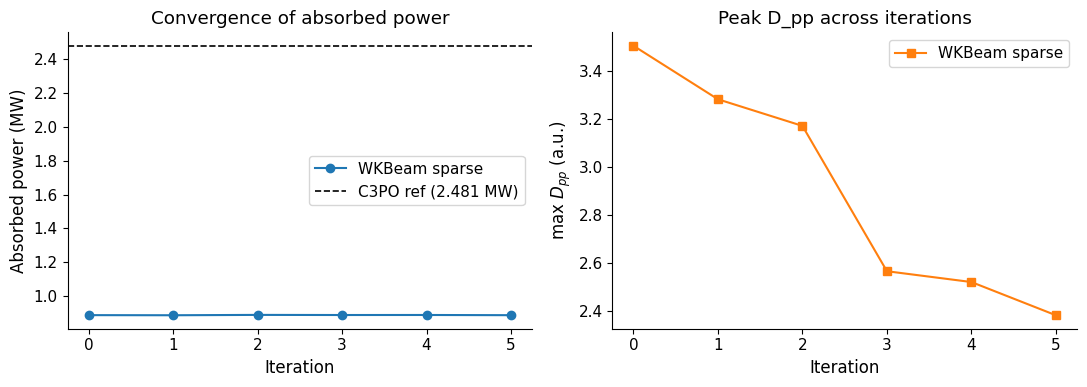

In [149]:
P_abs_arr   = np.array([np.trapz(data[it]['dP_drho'][:, 0], data[it]['rho_abs'])
                         for it in iters_avail])
DRF_max_arr = np.array([np.max(data[it]['DRF_pp']) for it in iters_avail])
P_abs_c3po  = np.trapz(c3po['absorption'], np.sqrt(c3po['psi']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(iters_avail, P_abs_arr, 'o-', color='C0', label='WKBeam sparse')
ax.axhline(P_abs_c3po, color='k', ls='--', lw=1.2, label=f'C3PO ref ({P_abs_c3po:.3f} MW)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Absorbed power (MW)')
ax.set_title('Convergence of absorbed power')
ax.set_xticks(iters_avail)
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax = axes[1]
ax.plot(iters_avail, DRF_max_arr, 's-', color='C1', label='WKBeam sparse')
ax.set_xlabel('Iteration')
ax.set_ylabel(r'max $D_{pp}$ (a.u.)')
ax.set_title('Peak D_pp across iterations')
ax.set_xticks(iters_avail)
ax.legend()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_convergence.png'), dpi=150)
plt.show()

## Absorption profiles — all iterations

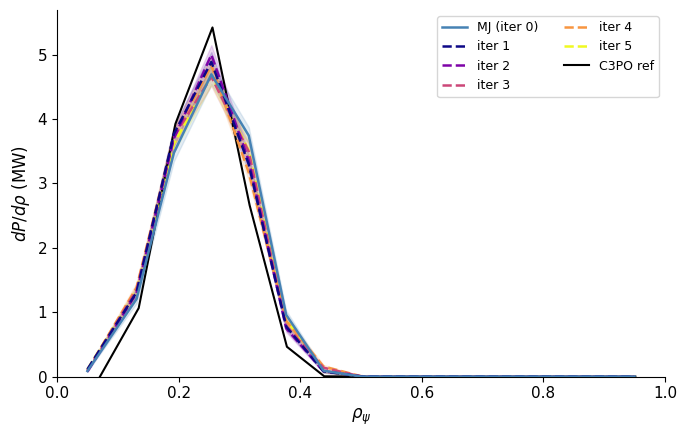

In [150]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for it in iters_avail:
    d   = data[it]
    lbl = 'MJ (iter 0)' if it == 0 else f'iter {it}'
    ls  = '-' if it == 0 else '--'
    ax.plot(d['rho_abs'], d['dP_drho'][:, 0], color=iter_color(it), ls=ls,
            lw=1.8, label=lbl, zorder=3 - 0.1*it)
    # uncertainty band
    ax.fill_between(d['rho_abs'],
                    d['dP_drho'][:, 0] - d['dP_drho'][:, 1],
                    d['dP_drho'][:, 0] + d['dP_drho'][:, 1],
                    alpha=0.15, color=iter_color(it))

rho_c3po = np.sqrt(c3po['psi'])
#find halfway locations in rho_c3po, and plot against these
rho_half = 0.5 * (rho_c3po[:-1] + rho_c3po[1:])
ax.plot(rho_c3po, c3po['absorption']/3, color='k', ls='-', lw=1.5, label='C3PO ref')

ax.set_xlabel(r'$\rho_{\psi}$')
ax.set_ylabel(r'$dP/d\rho$ (MW)')
ax.set_xlim(0, 1)
ax.set_ylim(0)
ax.legend(fontsize=9, ncol=2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_absorption_all.png'), dpi=150)
plt.show()

## Phase-space integrated D_pp vs rho — all iterations

/tmp/ipykernel_2506429/1179485867.py:15: RuntimeWarning: divide by zero encountered in divide
  axes[1].plot(rho_ref, DRF_int / (DRF_int_c3po), color=iter_color(it), ls=ls, lw=1.8, label=lbl)


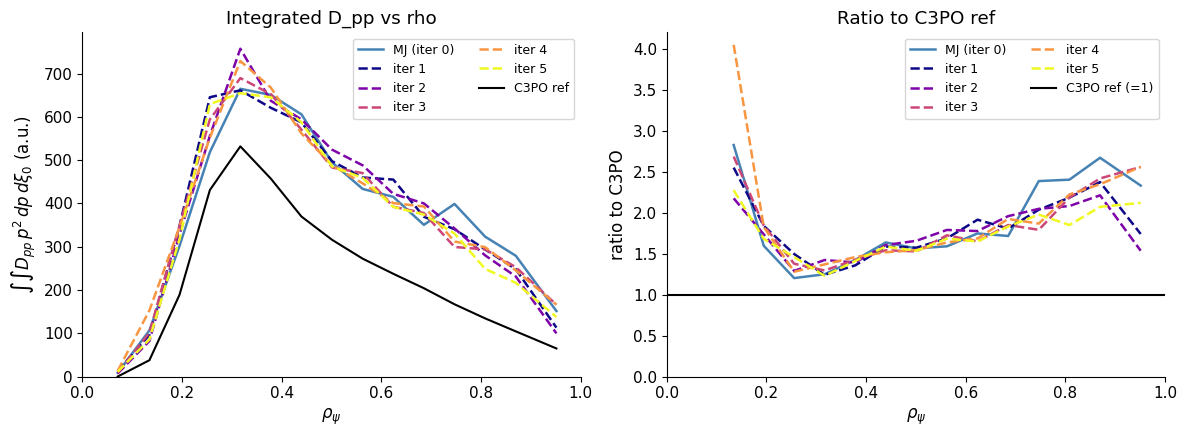

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
pmax = 8
# Reference psi from iter 0 (same for all iters)
psi_ref = data[iters_avail[0]]['psi']
rho_ref = np.sqrt(psi_ref)

DRF_int_c3po = integrate_phasespace(c3po['DRF_pp'], c3po['p'], c3po['ksi0'], p_max=p_max_plot)

for it in iters_avail:
    d   = data[it]
    lbl = 'MJ (iter 0)' if it == 0 else f'iter {it}'
    ls  = '-' if it == 0 else '--'
    DRF_int = integrate_phasespace(d['DRF_pp'], d['p_norm'], d['ksi0'], p_max=p_max_plot)
    axes[0].plot(rho_ref, DRF_int, color=iter_color(it), ls=ls, lw=1.8, label=lbl)
    axes[1].plot(rho_ref, DRF_int / (DRF_int_c3po), color=iter_color(it), ls=ls, lw=1.8, label=lbl)

axes[0].plot(np.sqrt(c3po['psi']), DRF_int_c3po, 'k-', lw=1.5, label='C3PO ref')
axes[1].axhline(1, color='k', ls='-', lw=1.5, label='C3PO ref (=1)')

for ax, ylabel, title in zip(axes,
    [r'$\int\int D_{pp}\,p^2\,dp\,d\xi_0$ (a.u.)',
     r'ratio to C3PO'],
    ['Integrated D_pp vs rho', 'Ratio to C3PO ref']):
    ax.set_xlabel(r'$\rho_{\psi}$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0)
    ax.legend(fontsize=9, ncol=2)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_DRFint_rho.png'), dpi=150)
plt.show()

## D_pp(p_par, p_perp) at selected rho — iteration grid

Rows: selected rho values.  Columns: subset of iterations + C3PO.  All share the same colour scale per row.

/tmp/ipykernel_2506429/968501605.py:36: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im  = ax.pcolormesh(Ppar, Pper, D, cmap=parula_map,
/tmp/ipykernel_2506429/968501605.py:64: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(Ppar_c, Pper_c, D_c, cmap=parula_map,


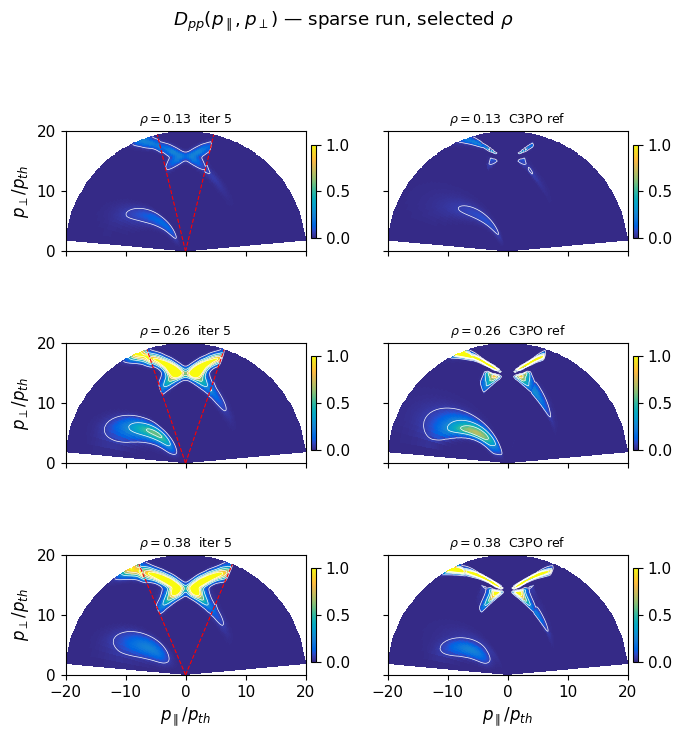

In [168]:
rho_goals    = [0.15, 0.25, 0.35]
iters_to_show = [it for it in [5] if it in data]

psi_ref  = data[iters_avail[0]]['psi']
p_norm   = data[iters_avail[0]]['p_norm']
ksi0     = data[iters_avail[0]]['ksi0']
Trapksi0 = data[iters_avail[0]]['Trapksi0']

Pnorm, Ksi0 = np.meshgrid(p_norm, ksi0)
Ppar = Pnorm * Ksi0
Pper = Pnorm * np.sqrt(np.clip(1 - Ksi0**2, 0, None))

Pnorm_c, Ksi0_c = np.meshgrid(c3po['p'], c3po['ksi0'])
Ppar_c = Pnorm_c * Ksi0_c
Pper_c = Pnorm_c * np.sqrt(np.clip(1 - Ksi0_c**2, 0, None))

n_cols = len(iters_to_show) + 1   # +1 for C3PO
n_rows = len(rho_goals)

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(3.5 * n_cols, 2.5 * n_rows),
                          sharex=True, sharey=True)

for ir, rho_goal in enumerate(rho_goals):
    ipsi    = np.argmin(np.abs(np.sqrt(psi_ref) - rho_goal))
    rho_val = np.sqrt(psi_ref[ipsi])
    trap    = Trapksi0[ipsi]

    # Per-row colour scale: max over all displayed iterations
    vmax = max(np.max(data[it]['DRF_pp'][:, :, ipsi]) for it in iters_to_show)
    vmax = 1#max(vmax, 1e-10)

    for ic, it in enumerate(iters_to_show):
        ax  = axes[ir, ic] if n_rows > 1 else axes[ic]
        D   = data[it]['DRF_pp'][:, :, ipsi]
        im  = ax.pcolormesh(Ppar, Pper, D, cmap=parula_map,
                             vmin=0, vmax=vmax, shading='auto')
        if vmax > 0:
            ax.contour(Ppar, Pper, D,
                        levels=np.linspace(0.05*vmax, vmax, 5),
                        colors='white', linewidths=0.5)
        # trapping boundary
        p_trap  = np.linspace(0, p_max_plot, 200)
        ax.plot( trap * p_trap,  np.sqrt(np.clip(1 - trap**2, 0, None)) * p_trap,
                'r--', lw=0.8)
        ax.plot(-trap * p_trap,  np.sqrt(np.clip(1 - trap**2, 0, None)) * p_trap,
                'r--', lw=0.8)
        ttl = 'MJ' if it == 0 else f'iter {it}'
        ax.set_title(rf'$\rho={rho_val:.2f}$  {ttl}', fontsize=9)
        ax.set_xlim(-p_max_plot, p_max_plot)
        ax.set_ylim(0, p_max_plot)
        ax.set_aspect('equal')
        plt.colorbar(im, ax=ax, pad=0.02, shrink=0.4)
        if ic == 0:
            ax.set_ylabel(r'$p_\perp/p_{th}$')
        if ir == n_rows - 1:
            ax.set_xlabel(r'$p_\parallel/p_{th}$')

    # C3PO reference column
    ax  = axes[ir, -1] if n_rows > 1 else axes[-1]
    ipsi_c = np.argmin(np.abs(np.sqrt(c3po['psi']) - rho_goal))
    D_c    = c3po['DRF_pp'][:, :, ipsi_c]
    vmax_c = 1#max(np.max(D_c), 1e-10)
    im = ax.pcolormesh(Ppar_c, Pper_c, D_c, cmap=parula_map,
                        vmin=0, vmax=vmax_c, shading='auto')
    ax.contour(Ppar_c, Pper_c, D_c,
                levels=np.linspace(0.05*vmax_c, vmax_c, 5),
                colors='white', linewidths=0.5)
    ax.set_title(rf'$\rho={rho_val:.2f}$  C3PO ref', fontsize=9)
    ax.set_xlim(-p_max_plot, p_max_plot)
    ax.set_ylim(0, p_max_plot)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, pad=0.02, shrink=0.4)
    if ir == n_rows - 1:
        ax.set_xlabel(r'$p_\parallel/p_{th}$')

plt.suptitle(r'$D_{pp}(p_\parallel, p_\perp)$ — sparse run, selected $\rho$', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_Dpp_2D.png'), dpi=150, bbox_inches='tight')
plt.show()

## D_pp integrated over pitch angle vs p — per rho, all iterations

$\int_{-1}^{1} D_{pp}(p,\xi_0)\,d\xi_0$ vs $p/p_{th}$ — shows the momentum dependence of the diffusion strength.

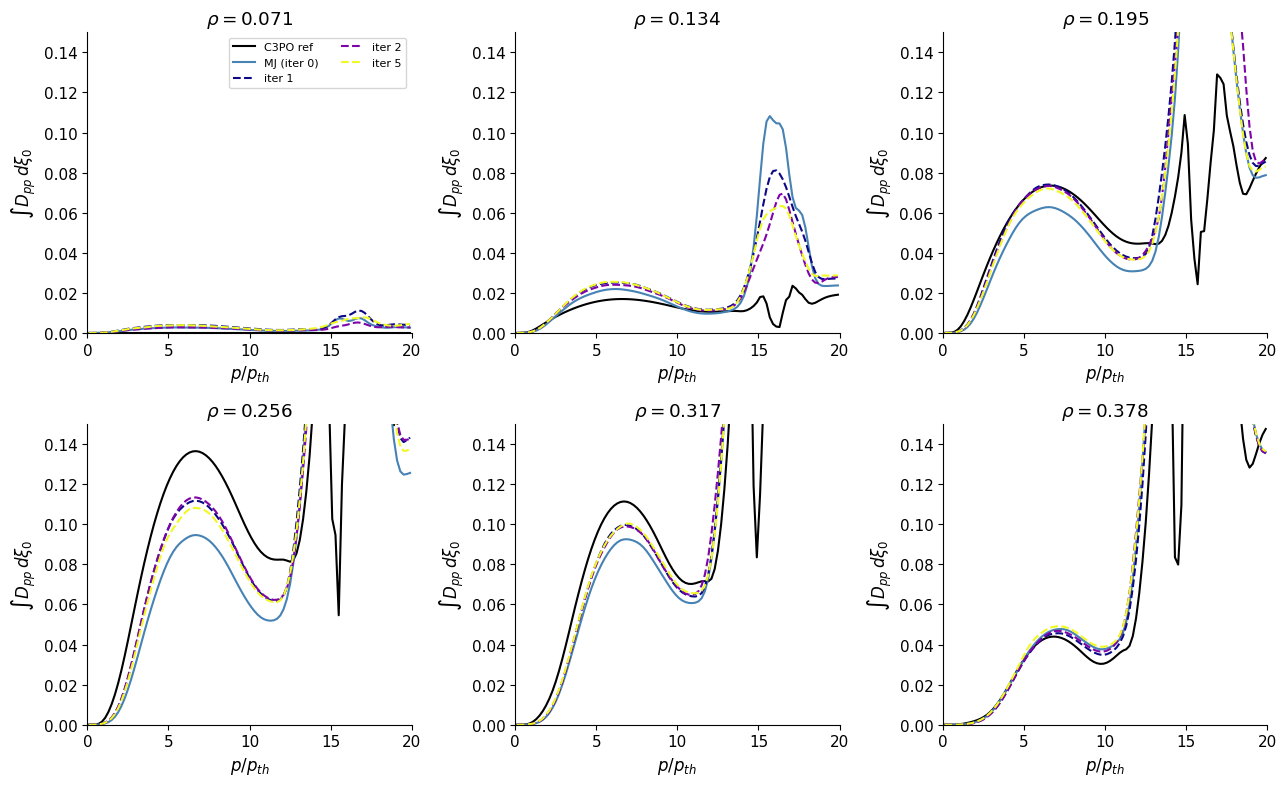

In [163]:
rho_goals = np.array([0.10, 0.15, 0.20, 0.25, 0.30, 0.35])
iters_avail = [0, 1, 2, 5]
ranges = np.array([6.8519000000000005, 6.784000000000001, 2.89426, 2.6537200000000003, 3.44855])
psi_ref   = data[iters_avail[0]]['psi']
p_norm    = data[iters_avail[0]]['p_norm']
ksi0      = data[iters_avail[0]]['ksi0']

ncols = 3
nrows = int(np.ceil(len(rho_goals) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows), sharey=False)
axes = axes.flatten()

for ax_idx, rho_goal in enumerate(rho_goals):
    ipsi    = np.argmin(np.abs(np.sqrt(psi_ref) - rho_goal))
    rho_val = np.sqrt(psi_ref[ipsi])
    ax      = axes[ax_idx]

    # C3PO reference
    ipsi_c  = np.argmin(np.abs(np.sqrt(c3po['psi']) - rho_goal))
    D_c_int = np.trapz(c3po['DRF_pp'][:, :, ipsi_c], c3po['ksi0'], axis=0)
    ax.plot(c3po['p'], D_c_int, color='k', ls='-', lw=1.5, label='C3PO ref')

    # WKBeam iterations
    for i, it in enumerate(iters_avail):
        d     = data[it]
        D_int = np.trapz(d['DRF_pp'][:, :, ipsi], d['ksi0'], axis=0)#*ranges[i]/np.pi
        lbl   = 'MJ (iter 0)' if it == 0 else f'iter {it}'
        ls    = '-' if it == 0 else '--'
        ax.plot(p_norm, D_int, color=iter_color(it), ls=ls, lw=1.5, label=lbl)

    ax.set_xlim(0, p_max_plot)
    ax.set_ylim(0, 0.15)
    ax.set_xlabel(r'$p / p_{th}$')
    ax.set_ylabel(r'$\int D_{pp}\,d\xi_0$')
    ax.set_title(rf'$\rho = {rho_val:.3f}$')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    if ax_idx == 0:
        ax.legend(fontsize=8, ncol=2)

for ax in axes[len(rho_goals):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_Dpp_xi_int.png'), dpi=150)
plt.show()

## D_pp at fixed p and rho vs ksi0 — iteration evolution

Shows how the pitch-angle distribution of D_pp changes iteration by iteration at the absorption peak.

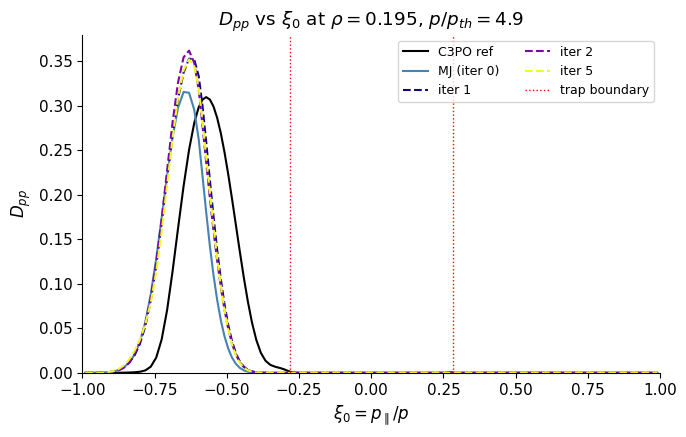

In [154]:
rho_goal = 0.20   # adjust to absorption peak
p_goal   = 5.0    # normalised momentum

psi_ref  = data[iters_avail[0]]['psi']
p_norm   = data[iters_avail[0]]['p_norm']
ksi0     = data[iters_avail[0]]['ksi0']

ipsi = np.argmin(np.abs(np.sqrt(psi_ref) - rho_goal))
ip   = np.argmin(np.abs(p_norm - p_goal))
rho_val = np.sqrt(psi_ref[ipsi])
p_val   = p_norm[ip]

fig, ax = plt.subplots(figsize=(7, 4.5))

ipsi_c = np.argmin(np.abs(np.sqrt(c3po['psi']) - rho_goal))
ip_c   = np.argmin(np.abs(c3po['p'] - p_goal))
ax.plot(c3po['ksi0'], c3po['DRF_pp'][:, ip_c, ipsi_c],
         color='k', ls='-', lw=1.5, label='C3PO ref')

for it in iters_avail:
    d   = data[it]
    lbl = 'MJ (iter 0)' if it == 0 else f'iter {it}'
    ls  = '-' if it == 0 else '--'
    ax.plot(ksi0, d['DRF_pp'][:, ip, ipsi],
             color=iter_color(it), ls=ls, lw=1.5, label=lbl)

ax.axvline( data[iters_avail[0]]['Trapksi0'][ipsi], color='r', ls=':', lw=1, label='trap boundary')
ax.axvline(-data[iters_avail[0]]['Trapksi0'][ipsi], color='r', ls=':', lw=1)
ax.set_xlabel(r'$\xi_0 = p_\parallel/p$')
ax.set_ylabel(r'$D_{pp}$')
ax.set_title(rf'$D_{{pp}}$ vs $\xi_0$ at $\rho={rho_val:.3f}$, $p/p_{{th}}={p_val:.1f}$')
ax.set_xlim(-1, 1)
ax.set_ylim(0)
ax.legend(fontsize=9, ncol=2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_Dpp_vs_ksi0.png'), dpi=150)
plt.show()

## Energy density components in binned data — (ρ, θ) maps

Three components stored in the sparse COO group of `L4_binned.hdf5`:
- **Wfct** (`BinnedTraces`): total wave energy density
- **cos φ_N** (`cos_phiN`): first Fourier harmonic of φ_N
- **cos 2φ_N** (`cos2_phiN`): second harmonic

Each component is summed over N_parallel and N_perp bins to give a 2-D (ρ, θ) map.

In [155]:
def load_binned(filename):
    """Load L4_binned.hdf5 and compute (rho, theta) marginals for the 3 energy-density components.

    Sparse COO layout:
        sparse/indices          (4, nnz) int32  — [irho, itheta, iNpar, iNperp] per nonzero
        sparse/values_BinnedTraces   (nnz,)      — Wfct
        sparse/values_cos_phiN       (nnz,)      — cos(phi_N) weighted
        sparse/values_cos2_phiN      (nnz,)      — cos(2*phi_N) weighted
    """
    with h5py.File(filename, 'r') as f:
        rhobins   = f['rhobins'][()]
        thetabins = f['Thetabins'][()]
        Nparbins  = f['Nparallelbins'][()]
        Nperpbins = f['Nperpbins'][()]
        shape     = tuple(f['sparse/shape'][()])   # (n_rho, n_theta, n_Npar, n_Nperp)
        indices   = f['sparse/indices'][()]        # (4, nnz)
        W0  = f['sparse/values_BinnedTraces'][()]
        Wc1 = f['sparse/values_cos_phiN'][()]
        Wc2 = f['sparse/values_cos2_phiN'][()]

    n_rho, n_theta = shape[0], shape[1]
    rho   = 0.5 * (rhobins[:-1]   + rhobins[1:])
    theta = 0.5 * (thetabins[:-1] + thetabins[1:])

    # (rho, theta) marginals: sum over N_par and N_perp
    E0  = np.zeros((n_rho, n_theta))
    Ec1 = np.zeros((n_rho, n_theta))
    Ec2 = np.zeros((n_rho, n_theta))
    ir, it = indices[0], indices[1]
    np.add.at(E0,  (ir, it), W0)
    np.add.at(Ec1, (ir, it), Wc1)
    np.add.at(Ec2, (ir, it), Wc2)

    return dict(
        rho=rho, theta=theta,
        rhobins=rhobins, thetabins=thetabins,
        Nparbins=Nparbins, Nperpbins=Nperpbins,
        E0=E0, Ec1=Ec1, Ec2=Ec2,
        nnz=len(W0),
    )


In [156]:
binned = {}
print('iter   nnz      E0_max      Ec1_max     Ec2_max')
for it in range(N_ITERS + 1):
    h5 = os.path.join(RUN_DIR, 'iter_%d' % it, 'output', 'L4_binned.hdf5')
    if not os.path.exists(h5):
        print('iter %d: not found' % it)
        continue
    b = load_binned(h5)
    binned[it] = b
    print('  %2d   %6d   %10.4e  %10.4e  %10.4e' % (
        it, b['nnz'], b['E0'].max(), abs(b['Ec1']).max(), abs(b['Ec2']).max()))

iters_bin = sorted(binned.keys())


iter   nnz      E0_max      Ec1_max     Ec2_max
   0    28250   6.7036e-01  1.6057e-02  6.6785e-01
   1    28604   6.8757e-01  1.6691e-02  6.8484e-01
   2    27788   6.2648e-01  1.7191e-02  6.2376e-01
   3    28943   6.3076e-01  1.6455e-02  6.2830e-01
   4    28730   6.0556e-01  1.7134e-02  6.0323e-01
   5    29679   6.3472e-01  1.5335e-02  6.3232e-01


### 2-D (θ, ρ) maps of the 3 components — selected iterations

Columns: Wfct, cos φ_N, cos 2φ_N.  Rows: selected iterations.

1.5759169999999998
1.620322
1.536658
1.5475214


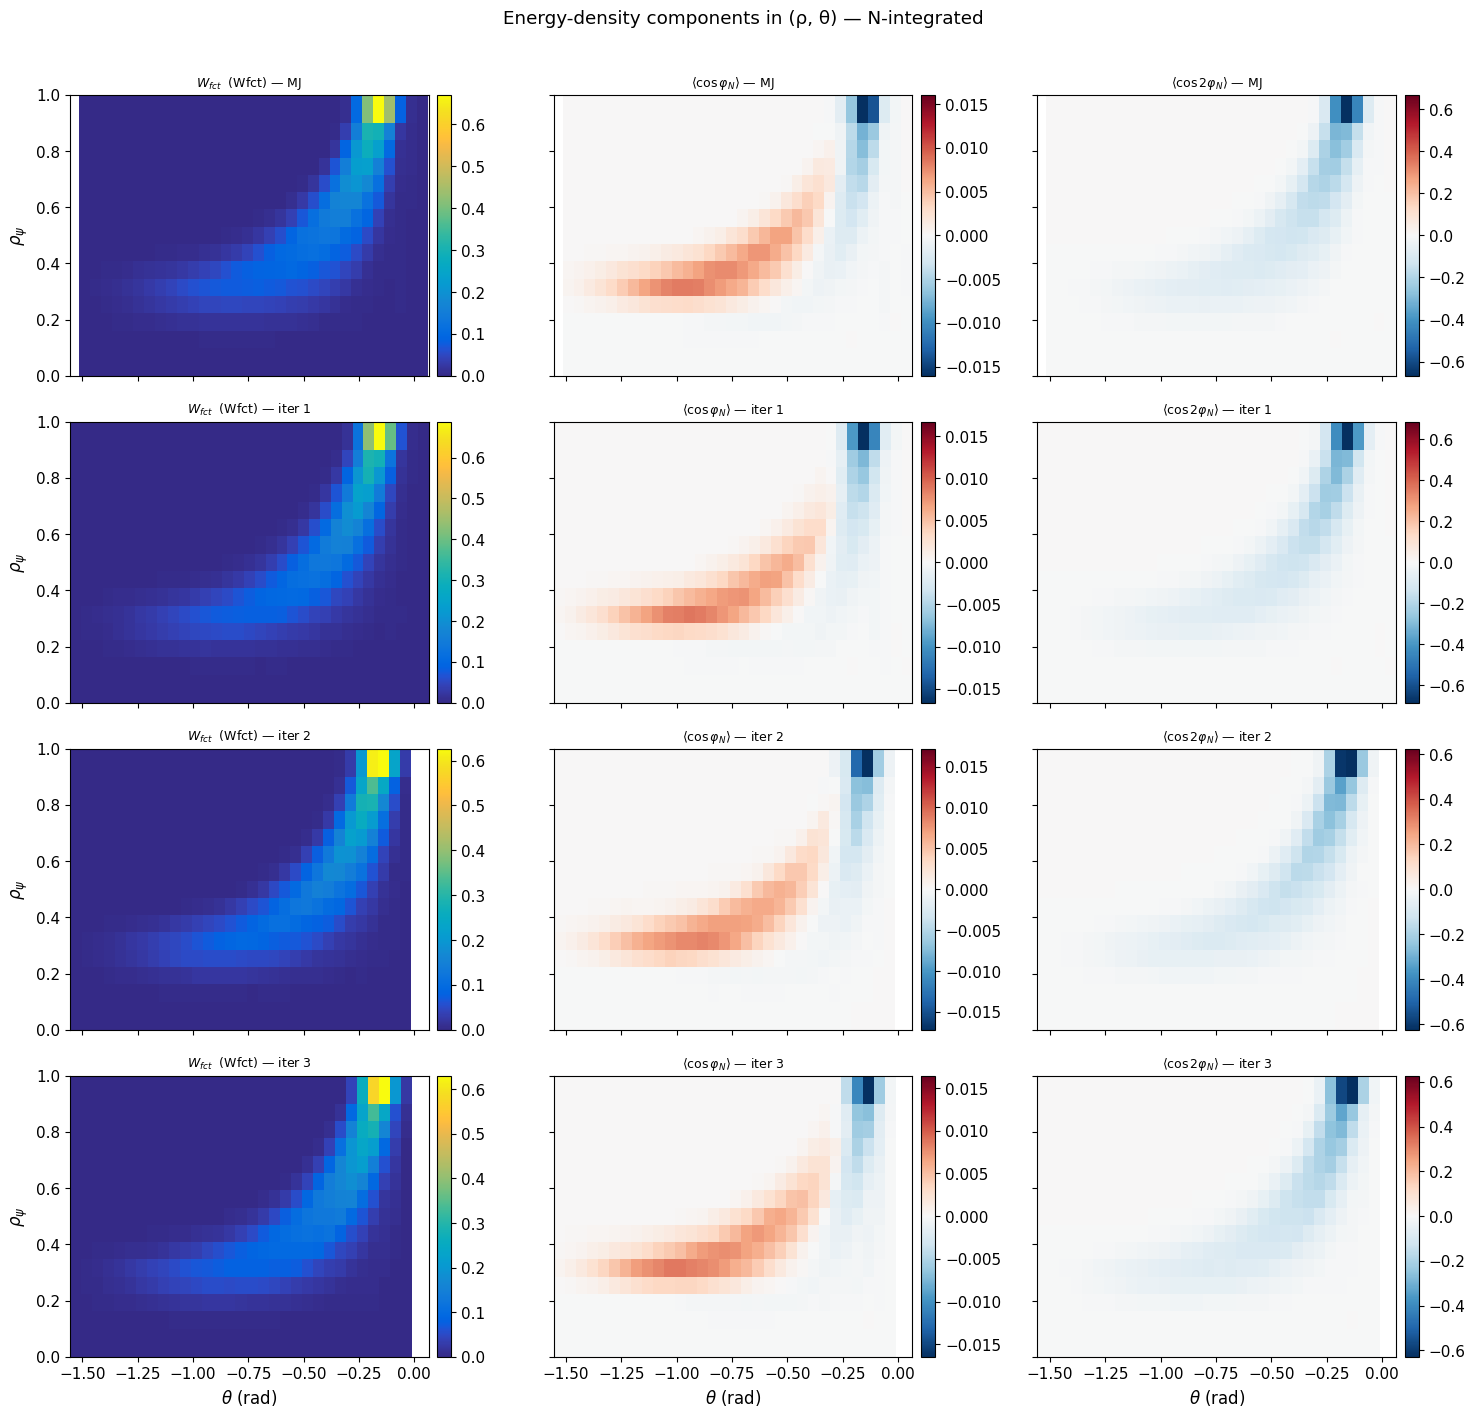

In [157]:
iters_show_bin = [it for it in [0, 1,2, 3] if it in binned]
comp_labels = [r'$W_{fct}$  (Wfct)', r'$\langle\cos\varphi_N\rangle$', r'$\langle\cos 2\varphi_N\rangle$']
comp_keys   = ['E0', 'Ec1', 'Ec2']
cmaps       = [parula_map, 'RdBu_r', 'RdBu_r']   # Ec1/Ec2 signed → diverging

n_rows = len(iters_show_bin)
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5 * n_cols, 3.5 * n_rows),
                          sharex=True, sharey=True)
if n_rows == 1:
    axes = axes[np.newaxis, :]

b0 = binned[iters_show_bin[0]]

for ir, it in enumerate(iters_show_bin):
    b = binned[it]
    # inside  for ir, it in enumerate(iters_show_bin):
    print(b['thetabins'].max() - b['thetabins'].min())

    THETA, RHO = np.meshgrid(b['thetabins'], b['rhobins'])   # ← per-iteration, not b0

    for ic, (key, label, cmap) in enumerate(zip(comp_keys, comp_labels, cmaps)):
        ax  = axes[ir, ic]
        D   = b[key]   # (n_rho, n_theta)
        if cmap == 'RdBu_r':
            vlim = max(abs(D.min()), abs(D.max()), 1e-30)
            im = ax.pcolormesh(THETA, RHO, D, cmap=cmap,
                                vmin=-vlim, vmax=vlim, shading='auto')
        else:
            im = ax.pcolormesh(THETA, RHO, D, cmap=cmap,
                                vmin=0, vmax=max(D.max(), 1e-30), shading='auto')
        plt.colorbar(im, ax=ax, pad=0.02)
        ttl = 'MJ' if it == 0 else 'iter %d' % it
        ax.set_title('%s — %s' % (label, ttl), fontsize=9)
        if ic == 0:
            ax.set_ylabel(r'$\rho_{\psi}$')
        if ir == n_rows - 1:
            ax.set_xlabel(r'$\theta$ (rad)')

plt.suptitle('Energy-density components in (ρ, θ) — N-integrated', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_Edens_rho_theta.png'), dpi=150, bbox_inches='tight')
plt.show()


### 1-D profiles: rho-integrated (vs θ) and θ-integrated (vs ρ)

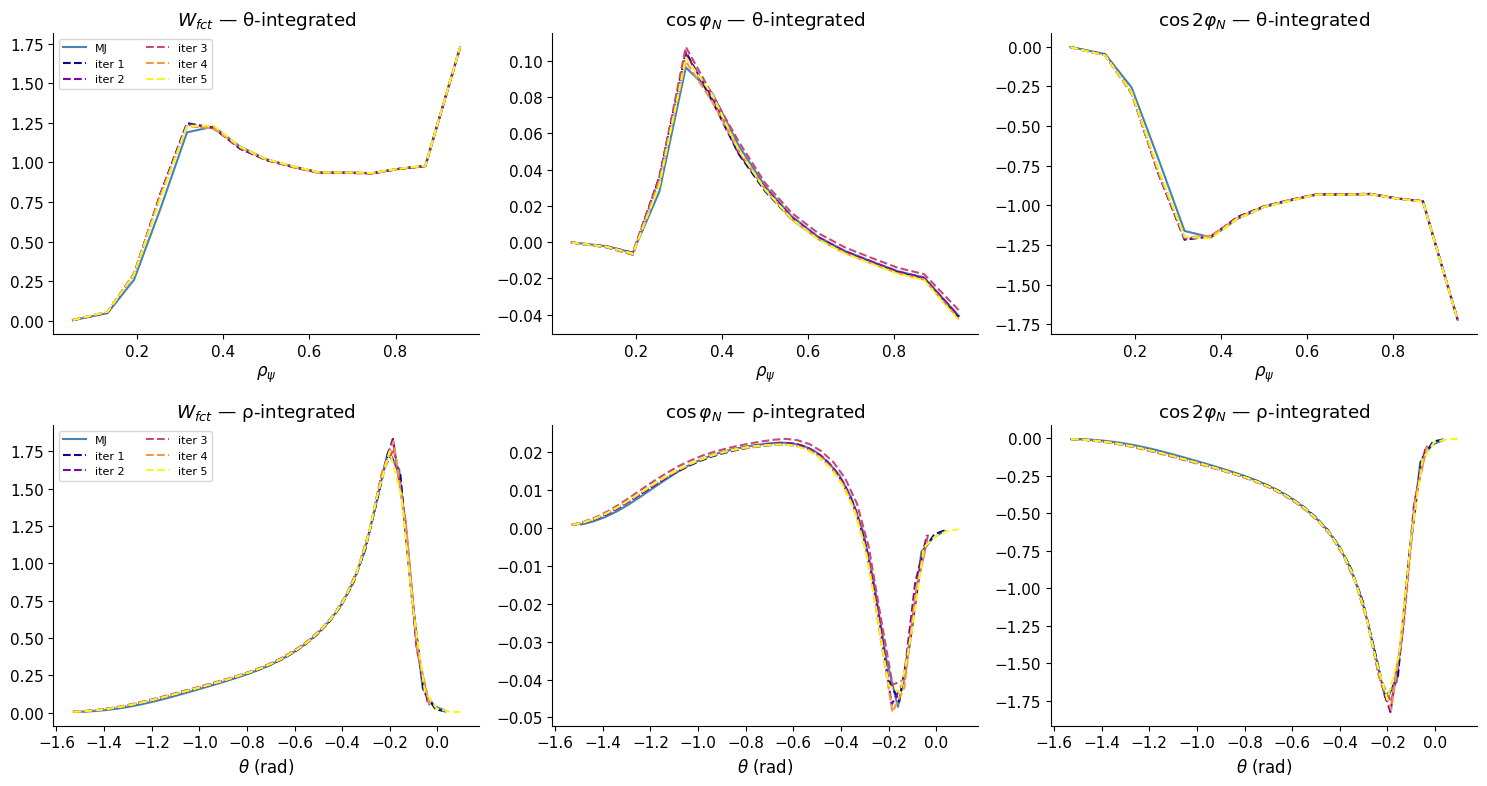

In [158]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
comp_keys   = ['E0', 'Ec1', 'Ec2']
comp_labels = [r'$W_{fct}$', r'$\cos\varphi_N$', r'$\cos 2\varphi_N$']

for ic, (key, label) in enumerate(zip(comp_keys, comp_labels)):
    ax_rho   = axes[0, ic]   # integrated over theta → vs rho
    ax_theta = axes[1, ic]   # integrated over rho   → vs theta

    for it in iters_bin:
        b   = binned[it]
        lbl = 'MJ' if it == 0 else 'iter %d' % it
        ls  = '-' if it == 0 else '--'
        col = iter_color(it)
        ax_rho.plot(b['rho'],   b[key].sum(axis=1), color=col, ls=ls, lw=1.5, label=lbl)
        ax_theta.plot(b['theta'], b[key].sum(axis=0), color=col, ls=ls, lw=1.5, label=lbl)

    ax_rho.set_xlabel(r'$\rho_{\psi}$')
    #ax_rho.set_ylabel(r'$\sum_\theta\,' + label + '$')
    ax_rho.set_title(label + ' — θ-integrated')
    ax_rho.spines['right'].set_visible(False); ax_rho.spines['top'].set_visible(False)

    ax_theta.set_xlabel(r'$\theta$ (rad)')
    #ax_theta.set_ylabel(r'$\sum_\rho\,' + label + '$')
    ax_theta.set_title(label + ' — ρ-integrated')
    ax_theta.spines['right'].set_visible(False); ax_theta.spines['top'].set_visible(False)

    if ic == 0:
        ax_rho.legend(fontsize=8, ncol=2)
        ax_theta.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_Edens_profiles.png'), dpi=150)
plt.show()


### Fourier ratio vs rho: ⟨cos φ_N⟩/Wfct and ⟨cos 2φ_N⟩/Wfct

The relative magnitude of the two Fourier components gives the effective φ_N anisotropy of the wave energy density at each ρ. Integrated over (θ, N_par, N_perp).

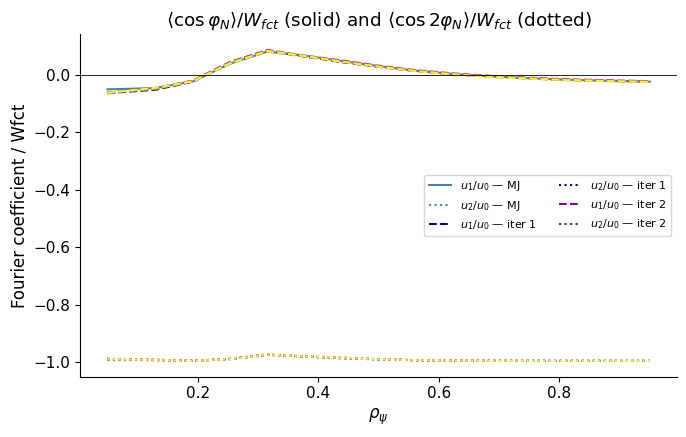

In [159]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for it in iters_bin:
    b     = binned[it]
    lbl   = 'MJ' if it == 0 else 'iter %d' % it
    ls    = '-' if it == 0 else '--'
    col   = iter_color(it)
    E0_r  = b['E0'].sum(axis=1) + 1e-30   # sum over theta → (n_rho,)
    Ec1_r = b['Ec1'].sum(axis=1)
    Ec2_r = b['Ec2'].sum(axis=1)
    ax.plot(b['rho'], Ec1_r / E0_r, color=col, ls=ls,     lw=1.5,
            label=(r'$u_1/u_0$ — ' + lbl) if it <= 2 else None)
    ax.plot(b['rho'], Ec2_r / E0_r, color=col, ls=':', lw=1.5,
            label=(r'$u_2/u_0$ — ' + lbl) if it <= 2 else None)

ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel(r'$\rho_{\psi}$')
ax.set_ylabel('Fourier coefficient / Wfct')
ax.set_title(r'$\langle\cos\varphi_N\rangle/W_{fct}$ (solid) and'
              r' $\langle\cos 2\varphi_N\rangle/W_{fct}$ (dotted)')
ax.legend(fontsize=8, ncol=2)
ax.spines['right'].set_visible(False); ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'QL_sparse_phiN_ratio.png'), dpi=150)
plt.show()
